In [ ]:
# Set -up tasks
# bring in all ENV variables in docker-compose/.env file
import os
import sys
# https://jakevdp.github.io/blog/2017/12/05/installing-python-packages-from-jupyter/
# Install a conda package in the current Jupyter kernel
!conda install --yes --quiet --prefix {sys.prefix} python-dotenv >> /dev/null
from dotenv import load_dotenv
ENV_dir = os.environ['HOME'] + '/mends-on-fhir/docker-compose'
os.chdir(ENV_dir)
load_dotenv()  # take environment variables from .env.
os.chdir(os.environ['JUPYTER_MENDS_HOME'])
print(os.getcwd())
# Steps 1 & 2: https://docs.docker.com/engine/install/ubuntu/
# Step 3: https://devopscube.com/run-docker-in-docker/ How to run docker in docker container [3 easy methods]
print("Done")

In [ ]:
%%bash
#curl -fsSL https://get.docker.com -o get-docker.sh && sudo sh get-docker.sh && sudo chmod 666 /var/run/docker.sock
if [ ! -f /usr/bin/docker ]
then
    curl -fsSL https://get.docker.com -o get-docker.sh && sudo sh get-docker.sh
else
    echo "Docker already installed"
fi
sudo chmod 666 /var/run/docker.sock
docker system prune -f >>/dev/null
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
bin/all-build.sh
bin/hapi-up.sh >/dev/null 2>&1 &
echo "Done"

# Welcome to the MENDS-on-FHIR demo presented by Andrey Soares, University of Colorado

## This demo converts OMOP CDM 5.3 into FHIR R4 US Core IG 4.0.0

This is an overview of the data flow. The unique feature is the Whistle JSON transformation engine and rules. 
This demo only shows the green colored data flows.
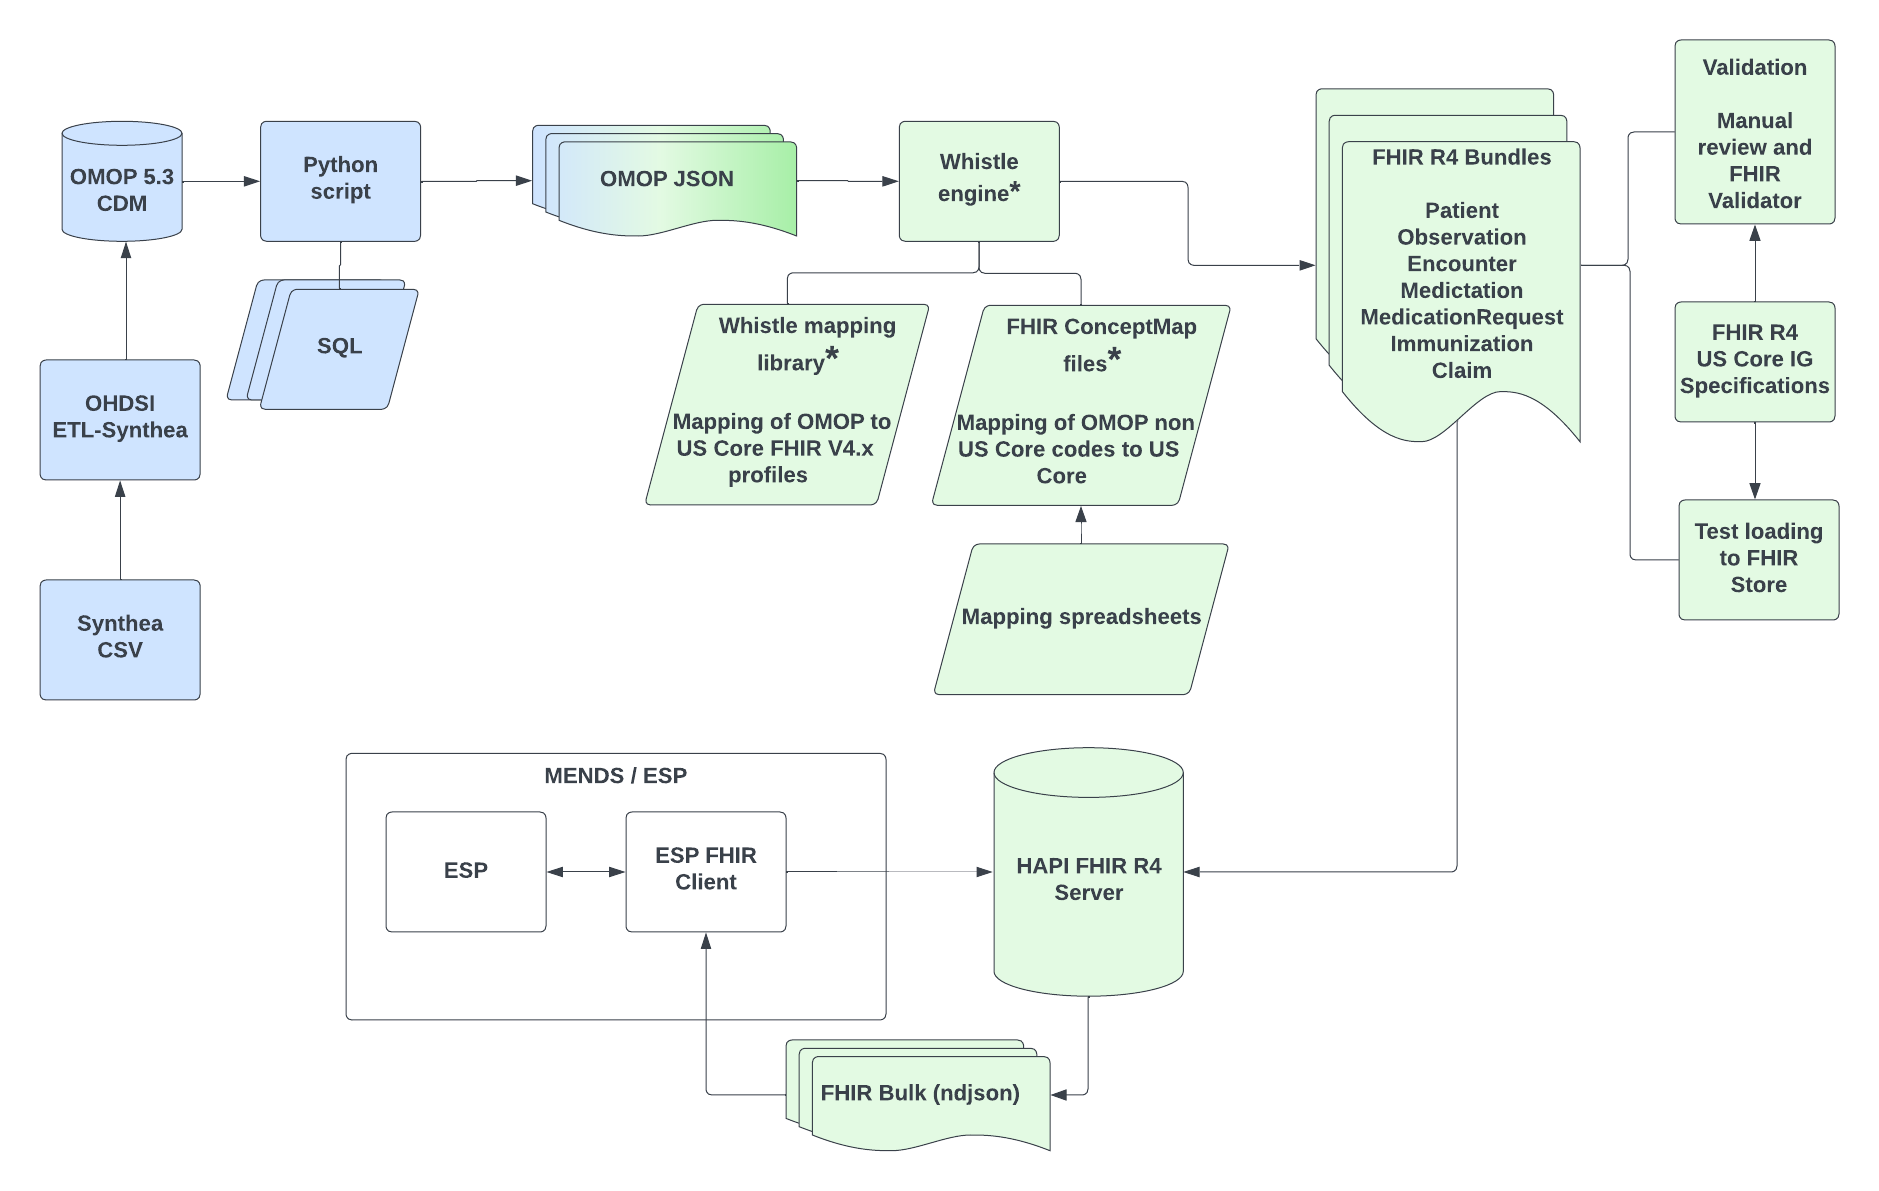

In this step, we convert OMOP in JSON format (OMOP JSON) into FHIR R4 USCore Bundles using the Whistle Transformation Engine

This is the starting OMOP JSON based on a standard OMOP SQL query

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
bin/omop-fhir-data-update.sh
cd ../input-examples/omop-fhir-data/synthea-cohort-010
head -n 100  Person_0000000000.json

This step executes the Whistle JSON-to-JSON transformation engine

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
bin/convert-reset.sh
bin/convert-up.sh
echo "Done"

This is what a Whistle transformation rule looks like
MGK: Add screen shot of Whistle rule

This is an example of a PERSON FHIR Bundle created from the OMOP JSON Person extract. 
This extract conforms to FHIR R4/US Core 4.0.1 specifications

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
head -n 100 convert/volume/output/Person_0000000000.output.json

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
head -n 100 convert/volume/output/Condition_Occurrence_0000000000.output.json

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
head -n 100 convert/volume/output/Visit_Occurrence_0000000000.output.json

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
head -n 100 convert/volume/output/Measurement_0000000000.output.json

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
head -n 100 convert/volume/output/Drug_Exposure_0000000000.output.json

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
bin/validate-reset.sh
bin/validate-up.sh
echo "Done"

In [ ]:
%%bash
cd $JUPYTER_MENDS_HOME
cd docker-compose
set -o allexport ; source .env ; set +o allexport
bin/load-reset.sh
bin/load-up.sh
echo "Done"